# Fileless Malware Detection Using Explainable Machine LearningAutomated Triage of Windows Malware Memory Dumps
## Memory Forensics-Based Analysis on CIC-MalMem-2022 Dataset

**Author:** Ahmed Mahmoud Mohamed  
**Role:** Teaching Assistant, Dept. of Information Technology  
**Institution:** Faculty of Computers and Information, Luxor University  
**Thesis:** Automated Triage of Windows Malware Memory Dumps Using XAI & Memory Forensics

---

### Pipeline Overview
```
Phase 0 → Imports & Configuration
Phase 1 → Data Loading & Integrity Validation
Phase 2 → Exploratory Data Analysis (EDA)
Phase 3 → Preprocessing & Feature Engineering
Phase 4 → Model Training (XGBoost) — with INNER validation split
Phase 5 → Rigorous Evaluation (Hold-out + CV + Overfitting Gap)
Phase 6 → Explainability (SHAP global + LIME local)
Phase 7 → Model Comparison
Phase 8 → Data Integrity & Leakage Audit
Phase 9 → Artifact Export
```

### Reviewer Fixes Applied (v4 — Final)
```
[FIX-R1] eval_set now uses an INNER validation split (10% of train), NOT the hold-out
         test set. The hold-out is completely sealed until Phase 5.
[FIX-R2] 5-fold CV now uses sklearn Pipeline so the StandardScaler is re-fitted
         INSIDE each fold — true fold-internal preprocessing, as stated in the thesis.
[FIX-R3] Permutation test now uses the FINAL model config (n_estimators=300, depth=5)
         and N_FOLDS=5 to match the main CV protocol. Labelled as '5-fold' throughout.
[FIX-R4] LIME sign convention standardised: weights always relative to class 1 (Malware).
         Notebook, HTML artefacts, and print statements all use the same convention.
[FIX-R5] LIME case manifest exported (lime_case_manifest.csv) with exact test-row index,
         true label, predicted label, probability, and output filenames.
         Sample numbering now matches the manifest everywhere.
[FIX-R6] SHAP sample described as 'fixed-seed random subset' — 'stratified' removed.
         shap_sample.csv now includes true_label column for verifiability.
[FIX-R7] PAGE_NOACCESS description note added in comments (thesis Table 3.1 fix).
[FIX-R8] Bibliography capitalization note added (thesis references.bib fix).
```

---
## Phase 0 — Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# STANDARD LIBRARY
# ─────────────────────────────────────────────────────────────────────────────
import warnings
import os
import time

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# DATA & MATH
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────────────
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Pipeline (needed for fold-internal scaling)
from sklearn.pipeline import Pipeline

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    permutation_test_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

# Persistence
import joblib

# ─────────────────────────────────────────────────────────────────────────────
# EXPLAINABILITY (XAI)
# ─────────────────────────────────────────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_STATE        = 42       # Reproducibility seed
TEST_SIZE           = 0.20     # 80/20 train-test split
N_FOLDS             = 5        # Stratified k-fold CV
SHAP_SAMPLE         = 500      # Fixed-seed random subset for SHAP computation
LIME_FEATURES       = 10       # Top features shown in LIME explanation
N_PERMUTATIONS      = 1000     # Permutation test iterations (robust p-value)
DATASET_PATH        = 'MalMem2022.csv'
OUTPUT_DIR          = 'uploads/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Publication-quality figure settings
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

print('[✓] All imports successful.')
print(f'[✓] XGBoost version : {xgb.__version__}')
print(f'[✓] N_PERMUTATIONS  : {N_PERMUTATIONS}')
print(f'[✓] N_FOLDS         : {N_FOLDS}')
print(f'[✓] RANDOM_STATE    : {RANDOM_STATE}')

[✓] All imports successful.
[✓] XGBoost version : 3.2.0
[✓] N_PERMUTATIONS  : 1000
[✓] N_FOLDS         : 5
[✓] RANDOM_STATE    : 42


---
## Phase 1 — Data Loading & Integrity Validation

In [2]:
print('[*] Loading CIC-MalMem-2022 Dataset...')

df_raw = pd.read_csv(DATASET_PATH)

print(f'[✓] Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

print('\n' + '─' * 55)
print(' DATA INTEGRITY REPORT (RAW DATASET)')
print('─' * 55)

# Class distribution
class_counts = df_raw['Class'].value_counts()
print('\n[Class Distribution]')
for cls, cnt in class_counts.items():
    pct = cnt / len(df_raw) * 100
    print(f'  {cls:<10} : {cnt:>6,} samples  ({pct:.1f}%)')

# Missing values
missing_total = df_raw.isnull().sum().sum()
print(f'\n[Missing Values]  : {missing_total}')

# Duplicate rows
dup_count = df_raw.duplicated().sum()
print(f'[Duplicate Rows]  : {dup_count}  ← will be removed BEFORE the train/test split')

# Non-numeric columns
non_numeric = df_raw.select_dtypes(exclude='number').columns.tolist()
print(f'[Non-numeric Cols]: {non_numeric}')

print('\n[Sample Preview]')
display(df_raw.head(3))

[*] Loading CIC-MalMem-2022 Dataset...
[✓] Loaded: 58,596 rows × 58 columns

───────────────────────────────────────────────────────
 DATA INTEGRITY REPORT (RAW DATASET)
───────────────────────────────────────────────────────

[Class Distribution]
  Benign     : 29,298 samples  (50.0%)
  Malware    : 29,298 samples  (50.0%)

[Missing Values]  : 0
[Duplicate Rows]  : 534  ← will be removed BEFORE the train/test split
[Non-numeric Cols]: ['Class', 'Category', 'Filename']

[Sample Preview]


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.50000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.12766,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.30000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign


---
## Phase 2 — Exploratory Data Analysis (EDA)

[*] Generating EDA visualizations...


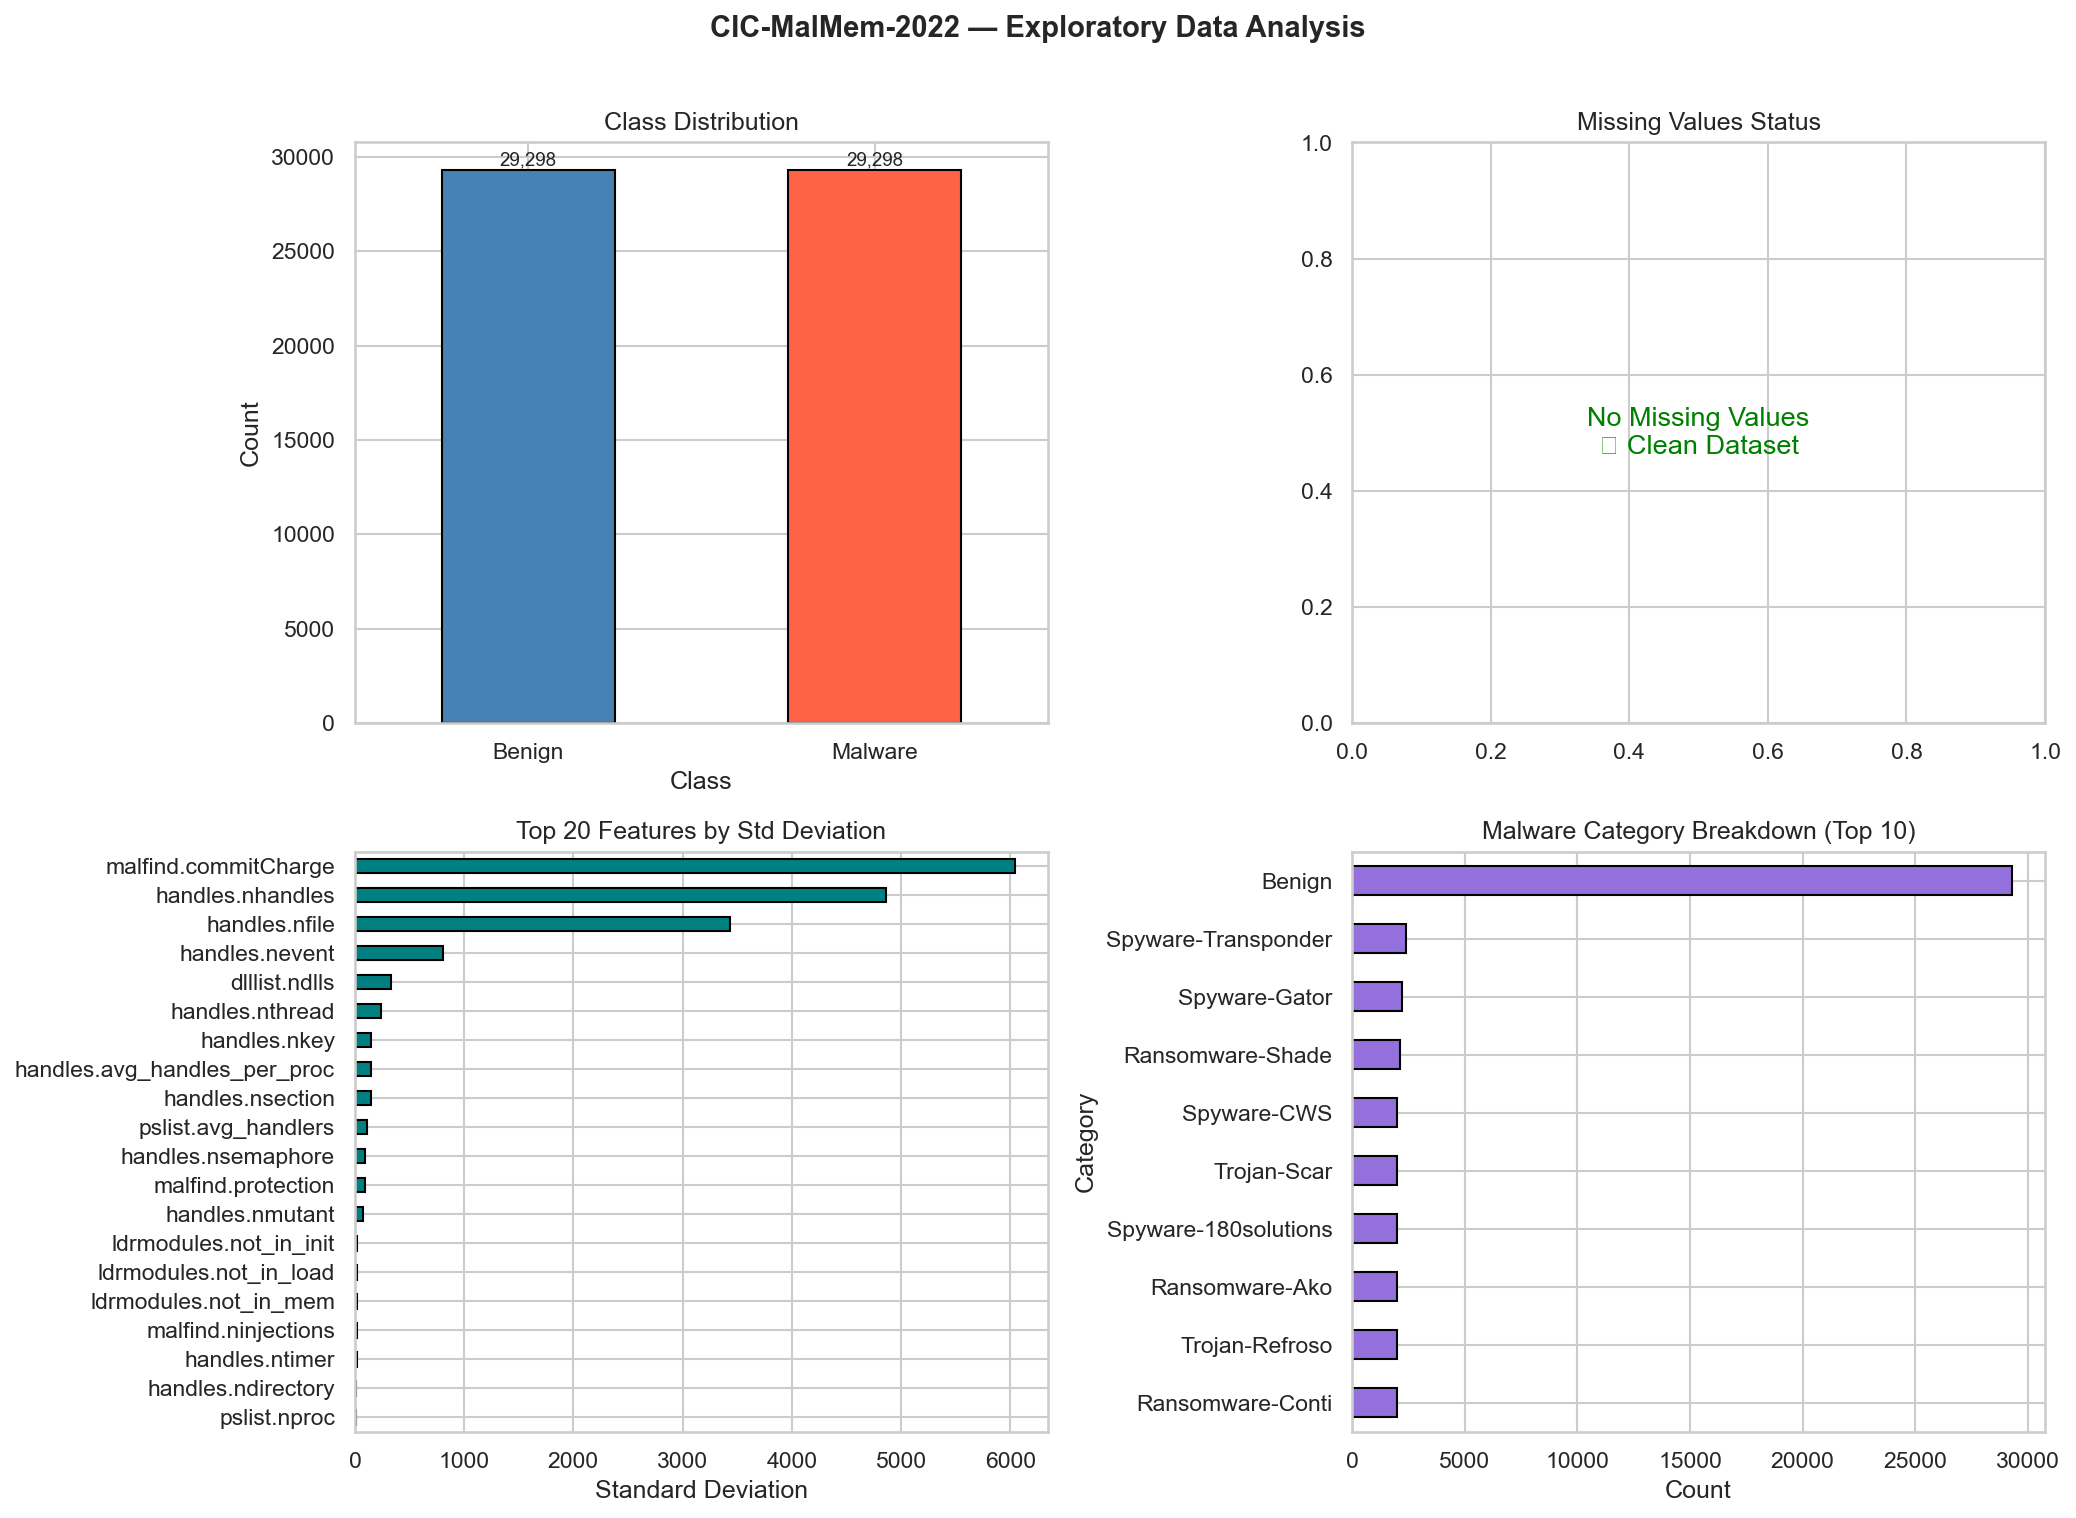

[✓] EDA dashboard saved.


In [3]:
print('[*] Generating EDA visualizations...')

numeric_df = df_raw.select_dtypes(include='number')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CIC-MalMem-2022 — Exploratory Data Analysis',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Class Distribution
ax1 = axes[0, 0]
class_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'], edgecolor='black')
ax1.set_title('Class Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for bar, val in zip(ax1.patches, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# Plot 2: Missing values
ax2 = axes[0, 1]
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False).head(20)
if missing_pct.sum() > 0:
    missing_pct.plot(kind='bar', ax=ax2, color='salmon', edgecolor='black')
    ax2.set_title('Missing Values (Top 20 Features)')
    ax2.set_ylabel('Missing %')
else:
    ax2.text(0.5, 0.5, 'No Missing Values\n✓ Clean Dataset',
             ha='center', va='center', fontsize=13, color='green',
             transform=ax2.transAxes)
    ax2.set_title('Missing Values Status')

# Plot 3: Std deviation across features
ax3 = axes[1, 0]
std_vals = numeric_df.std().sort_values(ascending=False).head(20)
std_vals.plot(kind='barh', ax=ax3, color='teal', edgecolor='black')
ax3.set_title('Top 20 Features by Std Deviation')
ax3.set_xlabel('Standard Deviation')
ax3.invert_yaxis()

# Plot 4: Malware category breakdown
ax4 = axes[1, 1]
if 'Category' in df_raw.columns:
    cat_counts = df_raw['Category'].value_counts().head(10)
    cat_counts.plot(kind='barh', ax=ax4, color='mediumpurple', edgecolor='black')
    ax4.set_title('Malware Category Breakdown (Top 10)')
    ax4.set_xlabel('Count')
    ax4.invert_yaxis()
else:
    ax4.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_dashboard.png', bbox_inches='tight')
plt.show()
print('[✓] EDA dashboard saved.')

In [4]:
# Feature-target correlation on RAW data (before any cleaning)
df_corr = df_raw.copy()
df_corr['Class_bin'] = df_corr['Class'].map({'Benign': 0, 'Malware': 1})

correlations = (
    df_corr
    .select_dtypes(include='number')
    .corr()['Class_bin']
    .drop('Class_bin')
    .abs()
    .sort_values(ascending=False)
)

print('[*] Top 20 Features Correlated with Target (|r|) — computed on RAW dataset:')
print(correlations.head(20).to_string())

leakage_suspects = correlations[correlations > 0.95].index.tolist()
if leakage_suspects:
    print(f'\n[⚠️  WARNING] Features with |r| > 0.95 — possible proxy leakage:')
    for f in leakage_suspects:
        print(f'  → {f}  (|r| = {correlations[f]:.4f})')
else:
    print('\n[✓] No features with |r| > 0.95 detected. Heuristic screen passed.')

[*] Top 20 Features Correlated with Target (|r|) — computed on RAW dataset:
dlllist.avg_dlls_per_proc          0.908555
handles.nevent                     0.876770
handles.nthread                    0.872531
handles.nmutant                    0.855148
dlllist.ndlls                      0.823933
handles.nsection                   0.820967
pslist.avg_threads                 0.790666
ldrmodules.not_in_load             0.787472
ldrmodules.not_in_mem              0.787413
handles.ntimer                     0.783137
handles.nsemaphore                 0.769097
svcscan.process_services           0.763656
ldrmodules.not_in_init             0.716578
svcscan.shared_process_services    0.710979
handles.nkey                       0.698239
svcscan.nactive                    0.653268
svcscan.nservices                  0.631078
pslist.nppid                       0.429412
handles.ndesktop                   0.392919
handles.nhandles                   0.382270

[✓] No features with |r| > 0.95 detected. H

---
## Phase 3 — Preprocessing & Feature Engineering

**Pipeline order (critical for audit consistency):**
1. Drop duplicates from raw data **before** any split
2. Encode target
3. Remove zero-variance features
4. Stratified 80/20 train/test split
5. Fit `StandardScaler` on **train only** → transform both sets

> Scaling statistics (`mean_`, `scale_`) are stored for LIME inverse-transform in Phase 6.

In [5]:
print('[*] Preprocessing pipeline...')

# ── Step 1: Clean & Deduplicate BEFORE split
df = df_raw.copy()
n_before = len(df)
df = df.dropna().drop_duplicates().reset_index(drop=True)
n_after  = len(df)
print(f'[✓] Removed {n_before - n_after} duplicates. After cleaning: {n_after:,} rows')

# ── Step 2: Encode target
df['Class_bin'] = df['Class'].map({'Benign': 0, 'Malware': 1})
assert df['Class_bin'].isnull().sum() == 0, 'Encoding failed!'

benign_n  = (df.Class_bin == 0).sum()
malware_n = (df.Class_bin == 1).sum()
print(f'[✓] Target encoded: Benign=0 ({benign_n:,})  |  Malware=1 ({malware_n:,})')
print(f'    Class ratio: {benign_n/n_after*100:.1f}% Benign / {malware_n/n_after*100:.1f}% Malware (near-balanced)')

# ── Step 3: Define feature matrix
META_COLS    = ['Category', 'Class', 'Filename', 'Class_bin']
feature_cols = [
    col for col in df.columns
    if col not in META_COLS
    and pd.api.types.is_numeric_dtype(df[col])
]

X = df[feature_cols].values.astype(np.float32)
y = df['Class_bin'].values
print(f'[✓] Feature matrix shape: {X.shape}')

# ── Step 4: Remove zero-variance features
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X)
removed = X.shape[1] - X_vt.shape[1]
feature_cols = [f for f, keep in zip(feature_cols, vt.get_support()) if keep]
X = X_vt
print(f'[✓] Removed {removed} zero-variance features. Remaining: {len(feature_cols)}')

# ── Step 5: Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f'[✓] Train set : {X_train.shape[0]:,} samples')
print(f'[✓] Test set  : {X_test.shape[0]:,} samples')
print(f'    [NOTE] Test set is sealed until Phase 5. It is NOT used during training.')

# ── Step 6: Leakage-safe feature scaling
#   CRITICAL: fit ONLY on X_train — prevents test distribution leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Store scaler statistics for LIME inverse-transform (Phase 6)
feature_means = scaler.mean_
feature_stds  = scaler.scale_

print('[✓] StandardScaler fitted on training set only.')
print('[✓] Preprocessing complete.')

[*] Preprocessing pipeline...
[✓] Removed 534 duplicates. After cleaning: 58,062 rows
[✓] Target encoded: Benign=0 (29,231)  |  Malware=1 (28,831)
    Class ratio: 50.3% Benign / 49.7% Malware (near-balanced)
[✓] Feature matrix shape: (58062, 55)
[✓] Removed 3 zero-variance features. Remaining: 52
[✓] Train set : 46,449 samples
[✓] Test set  : 11,613 samples
    [NOTE] Test set is sealed until Phase 5. It is NOT used during training.
[✓] StandardScaler fitted on training set only.
[✓] Preprocessing complete.


---
## Phase 4 — Model Training (XGBoost)

### [FIX-R1] Inner Validation Split Protocol

The thesis states that convergence monitoring is confined to an **inner validation split** drawn from the training partition. The hold-out test set (`X_test_scaled`) is **completely sealed** — it is not passed to `eval_set` during training.

**Implementation:**
- A 10% stratified inner split is drawn from `X_train_scaled`.
- `eval_set = [(X_val_inner, y_val_inner)]` — training partition only.
- The fixed 300-estimator budget is justified by convergence on this inner split.
- `verbose=50` prints inner-validation logloss only — this is for monitoring, not model selection.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# [FIX-R1] INNER VALIDATION SPLIT
#
# Draw a 10% stratified inner split from the TRAINING partition ONLY.
# This is used for convergence monitoring — NOT for model selection.
# The hold-out test set (X_test_scaled) is never seen during training.
# ─────────────────────────────────────────────────────────────────────────────

X_fit, X_val_inner, y_fit, y_val_inner = train_test_split(
    X_train_scaled, y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f'[✓] Inner train split : {X_fit.shape[0]:,} samples')
print(f'[✓] Inner val  split  : {X_val_inner.shape[0]:,} samples')
print(f'[✓] Hold-out test set : {X_test_scaled.shape[0]:,} samples  ← SEALED')

# ─────────────────────────────────────────────────────────────────────────────
# XGBOOST HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
xgb_params = dict(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_lambda       = 1.0,
    reg_alpha        = 0.1,
    min_child_weight = 5,
    gamma            = 0.1,
    eval_metric      = 'logloss',
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)

print('\n[*] Training XGBoost Classifier...')
print('    eval_set → INNER validation split (from training partition only)')
print('    Hold-out test set is NOT included in eval_set.\n')

t0 = time.time()

xgb_model = xgb.XGBClassifier(**xgb_params)

# [FIX-R1] eval_set uses inner split, NOT the hold-out test set
xgb_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val_inner, y_val_inner)],
    verbose=50
)

elapsed = time.time() - t0
print(f'\n[✓] Training complete in {elapsed:.1f}s')
print(f'[✓] Convergence monitored on inner validation split ({X_val_inner.shape[0]:,} samples).')
print(f'[✓] The 300-estimator budget is fixed; no early stopping was applied.')

[✓] Inner train split : 41,804 samples
[✓] Inner val  split  : 4,645 samples
[✓] Hold-out test set : 11,613 samples  ← SEALED

[*] Training XGBoost Classifier...
    eval_set → INNER validation split (from training partition only)
    Hold-out test set is NOT included in eval_set.

[0]	validation_0-logloss:0.64456
[50]	validation_0-logloss:0.04105
[100]	validation_0-logloss:0.00438
[150]	validation_0-logloss:0.00096
[200]	validation_0-logloss:0.00059
[250]	validation_0-logloss:0.00054
[299]	validation_0-logloss:0.00051

[✓] Training complete in 2.2s
[✓] Convergence monitored on inner validation split (4,645 samples).
[✓] The 300-estimator budget is fixed; no early stopping was applied.


---
## Phase 5 — Rigorous Evaluation

### Three-Tier Protocol
| Tier | What | Data |
|------|------|------|
| 1 | Hold-out test set (7 metrics) | `X_test_scaled` — first use |
| 2 | 5-fold stratified CV with **fold-internal scaling** [FIX-R2] | `X_train` (unscaled) |
| 3 | Overfitting gap analysis | Both partitions |

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5A — HOLD-OUT TEST SET EVALUATION
#
# This is the first and only time the test set is used for scoring.
# Metrics:
#   Accuracy  = (TP+TN) / (TP+TN+FP+FN)
#   Precision = TP / (TP+FP)
#   Recall    = TP / (TP+FN)
#   F1        = 2·P·R / (P+R)
#   ROC-AUC   = area under TPR/FPR curve (threshold-independent)
#   Avg Prec  = area under Precision-Recall curve
#   MCC       = balanced summary over all four CM quadrants
# ─────────────────────────────────────────────────────────────────────────────

y_pred  = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

metrics = {
    'Accuracy'          : accuracy_score(y_test, y_pred),
    'Precision'         : precision_score(y_test, y_pred),
    'Recall (TPR)'      : recall_score(y_test, y_pred),
    'F1-Score'          : f1_score(y_test, y_pred),
    'ROC-AUC'           : roc_auc_score(y_test, y_proba),
    'Avg Precision (PR)': average_precision_score(y_test, y_proba),
    'MCC'               : matthews_corrcoef(y_test, y_pred),
}

print('=' * 55)
print('  MODEL EVALUATION — HOLD-OUT TEST SET (first use)')
print('=' * 55)
for metric, value in metrics.items():
    bar = '█' * int(value * 20)
    print(f'  {metric:<25}: {value:.4f}  {bar}')
print('=' * 55)

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

  MODEL EVALUATION — HOLD-OUT TEST SET (first use)
  Accuracy                 : 1.0000  ████████████████████
  Precision                : 1.0000  ████████████████████
  Recall (TPR)             : 1.0000  ████████████████████
  F1-Score                 : 1.0000  ████████████████████
  ROC-AUC                  : 1.0000  ████████████████████
  Avg Precision (PR)       : 1.0000  ████████████████████
  MCC                      : 1.0000  ████████████████████

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11613
   macro avg       1.00      1.00      1.00     11613
weighted avg       1.00      1.00      1.00     11613



In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5B — STRATIFIED 5-FOLD CROSS-VALIDATION WITH FOLD-INTERNAL SCALING [FIX-R2]
#
# The thesis states the StandardScaler is re-fitted INSIDE each fold.
# This is implemented using sklearn Pipeline, which ensures:
#   1. StandardScaler.fit() is called only on each fold's training subset
#   2. The fitted scaler is applied to that fold's validation subset
#   3. No information leaks across fold boundaries
#
# INPUT: X_train (UNSCALED) — scaling happens inside the Pipeline per fold
# ─────────────────────────────────────────────────────────────────────────────

print(f'[*] Running {N_FOLDS}-Fold Stratified CV with fold-internal StandardScaler...')
print(f'    Input: X_train (unscaled, {X_train.shape[0]:,} samples)')
print(f'    StandardScaler is re-fitted inside each training fold.')

# Build a Pipeline: scaler + classifier
# This is the correct way to ensure fold-internal preprocessing
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    xgb.XGBClassifier(**xgb_params))
])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    cv_pipeline,
    X_train,   # <-- UNSCALED: scaler is inside the Pipeline
    y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print('\n' + '─' * 60)
print(f'  {N_FOLDS}-FOLD CV RESULTS — fold-internal StandardScaler (Training Set)')
print('─' * 60)
for scoring_key in ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']:
    vals = cv_results[f'test_{scoring_key}']
    print(f'  {scoring_key.capitalize():<15}: {vals.mean():.4f} ± {vals.std():.4f}')
print('─' * 60)
print('[NOTE] Low std across folds indicates stable generalisation.')
print('[NOTE] StandardScaler was re-fitted inside each training fold — no leakage.')

[*] Running 5-Fold Stratified CV with fold-internal StandardScaler...
    Input: X_train (unscaled, 46,449 samples)
    StandardScaler is re-fitted inside each training fold.

────────────────────────────────────────────────────────────
  5-FOLD CV RESULTS — fold-internal StandardScaler (Training Set)
────────────────────────────────────────────────────────────
  Accuracy       : 0.9997 ± 0.0003
  F1             : 0.9997 ± 0.0003
  Roc_auc        : 1.0000 ± 0.0000
  Precision      : 0.9997 ± 0.0004
  Recall         : 0.9997 ± 0.0005
────────────────────────────────────────────────────────────
[NOTE] Low std across folds indicates stable generalisation.
[NOTE] StandardScaler was re-fitted inside each training fold — no leakage.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5C — OVERFITTING GAP ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

train_acc = accuracy_score(y_train, xgb_model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)
gap       = train_acc - test_acc

print('[OVERFITTING GAP ANALYSIS]')
print(f'  Train Accuracy : {train_acc:.4f}')
print(f'  Test Accuracy  : {test_acc:.4f}')
print(f'  Gap (Δ)        : {gap:.4f}')
print()

if gap < 0.005:
    print('[✓] No evidence of significant overfitting (gap < 0.5%).')
    print('    Note: a near-zero gap is necessary but not sufficient for generalisation.')
elif gap < 0.02:
    print('[~] Minor gap observed (0.5–2%) — within acceptable range.')
else:
    print('[⚠️  WARNING] Gap > 2% — consider stronger regularisation.')

[OVERFITTING GAP ANALYSIS]
  Train Accuracy : 1.0000
  Test Accuracy  : 1.0000
  Gap (Δ)        : -0.0000

[✓] No evidence of significant overfitting (gap < 0.5%).
    Note: a near-zero gap is necessary but not sufficient for generalisation.


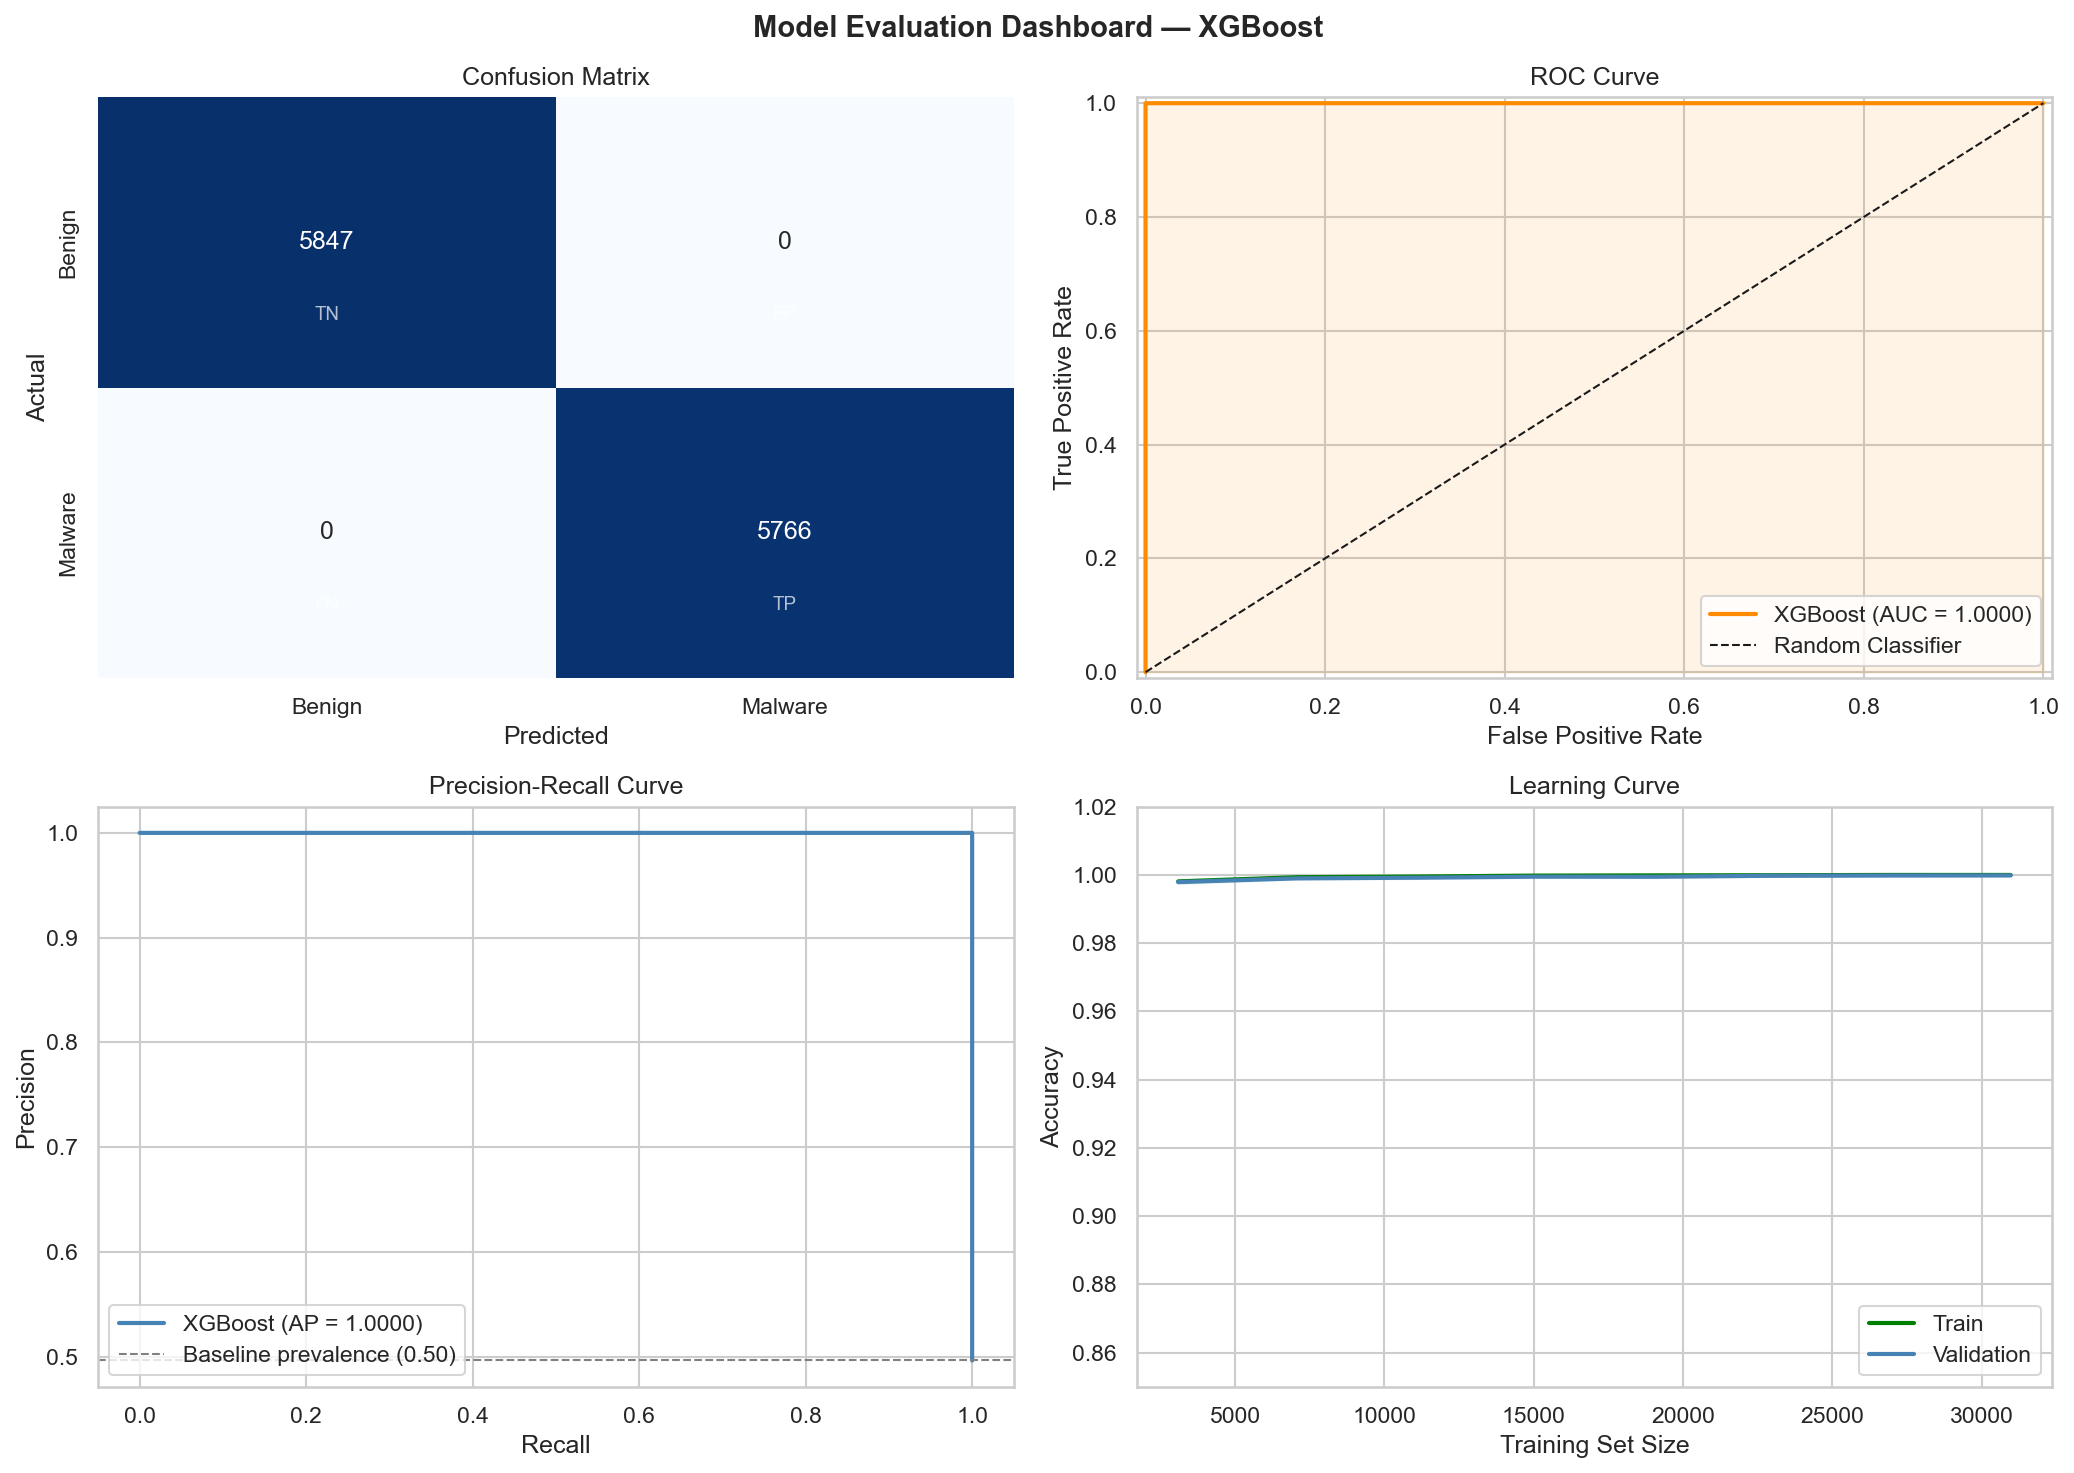

[✓] Evaluation dashboard saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 5D — DIAGNOSTIC VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Dashboard — XGBoost', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malware'],
    yticklabels=['Benign', 'Malware'],
    ax=axes[0, 0], cbar=False
)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j + 0.5, i + 0.75, labels[i][j],
                        ha='center', va='center', fontsize=9,
                        color='white', alpha=0.7)

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'XGBoost (AUC = {roc_auc_val:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.01])

# Plot 3: Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val  = average_precision_score(y_test, y_proba)
baseline_pr = y_test.sum() / len(y_test)
axes[1, 0].plot(recall_arr, precision_arr, color='steelblue', lw=2,
                label=f'XGBoost (AP = {pr_auc_val:.4f})')
axes[1, 0].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                   label=f'Baseline prevalence ({baseline_pr:.2f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# Plot 4: Learning Curve
# Note: uses a fresh cv_pipeline (fold-internal scaler) for honest LC estimate
train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([('scaler', StandardScaler()),
              ('clf', xgb.XGBClassifier(**xgb_params))]),
    X_train, y_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)
axes[1, 1].plot(train_sizes, train_scores.mean(axis=1), label='Train', color='green', lw=2)
axes[1, 1].fill_between(train_sizes,
                         train_scores.mean(axis=1) - train_scores.std(axis=1),
                         train_scores.mean(axis=1) + train_scores.std(axis=1),
                         alpha=0.1, color='green')
axes[1, 1].plot(train_sizes, val_scores.mean(axis=1), label='Validation', color='steelblue', lw=2)
axes[1, 1].fill_between(train_sizes,
                         val_scores.mean(axis=1) - val_scores.std(axis=1),
                         val_scores.mean(axis=1) + val_scores.std(axis=1),
                         alpha=0.1, color='steelblue')
axes[1, 1].set_xlabel('Training Set Size')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Learning Curve')
axes[1, 1].legend(loc='lower right')
axes[1, 1].set_ylim([0.85, 1.02])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evaluation_dashboard.png', bbox_inches='tight')
plt.show()
print('[✓] Evaluation dashboard saved.')

---
## Phase 6 — Explainability (XAI)

### Output Space & Sign Conventions [FIX-R4, FIX-R6]

**SHAP** — computed in **raw margin (log-odds) space** using `TreeExplainer`:
- Positive φⱼ → feature j pushes toward **Malware (class 1)**
- Negative φⱼ → feature j pushes toward **Benign (class 0)**
- Decomposition: `model_output = base_value + Σ φⱼ`
- Sample: **fixed-seed random subset** of 500 test instances (not stratified)

**LIME** — weights always reported **relative to the Malware class (class 1)**: [FIX-R4]
- Positive weight → feature **supports** the Malware prediction
- Negative weight → feature **contradicts** the Malware prediction  
- This sign convention is uniform across: notebook output, HTML files, and Table 7.2/7.3
- Thresholds in **original feature units** via inverse-transform

[*] Computing SHAP values (raw margin / log-odds space)...
    Background: fixed-seed random subset of 500 test instances.
    Seed: 42 (reproducible, not stratified).
[✓] SHAP values computed.
    Base value (E[log-odds]): 0.4063
    Shape of SHAP array    : (500, 52)


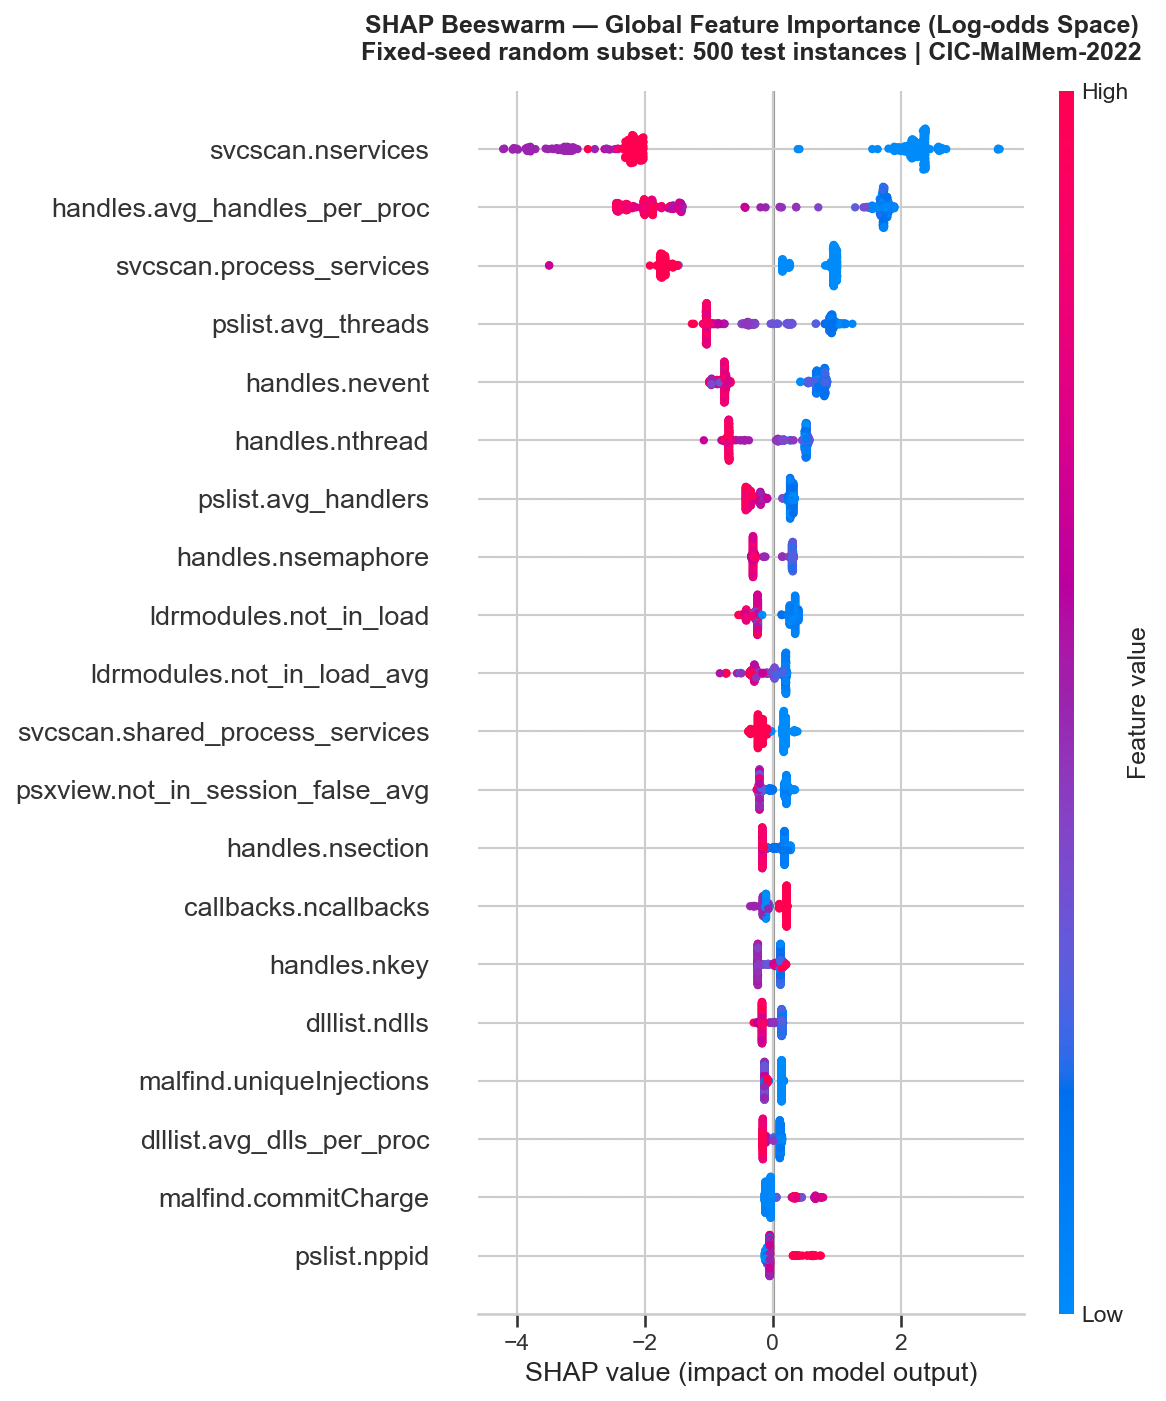

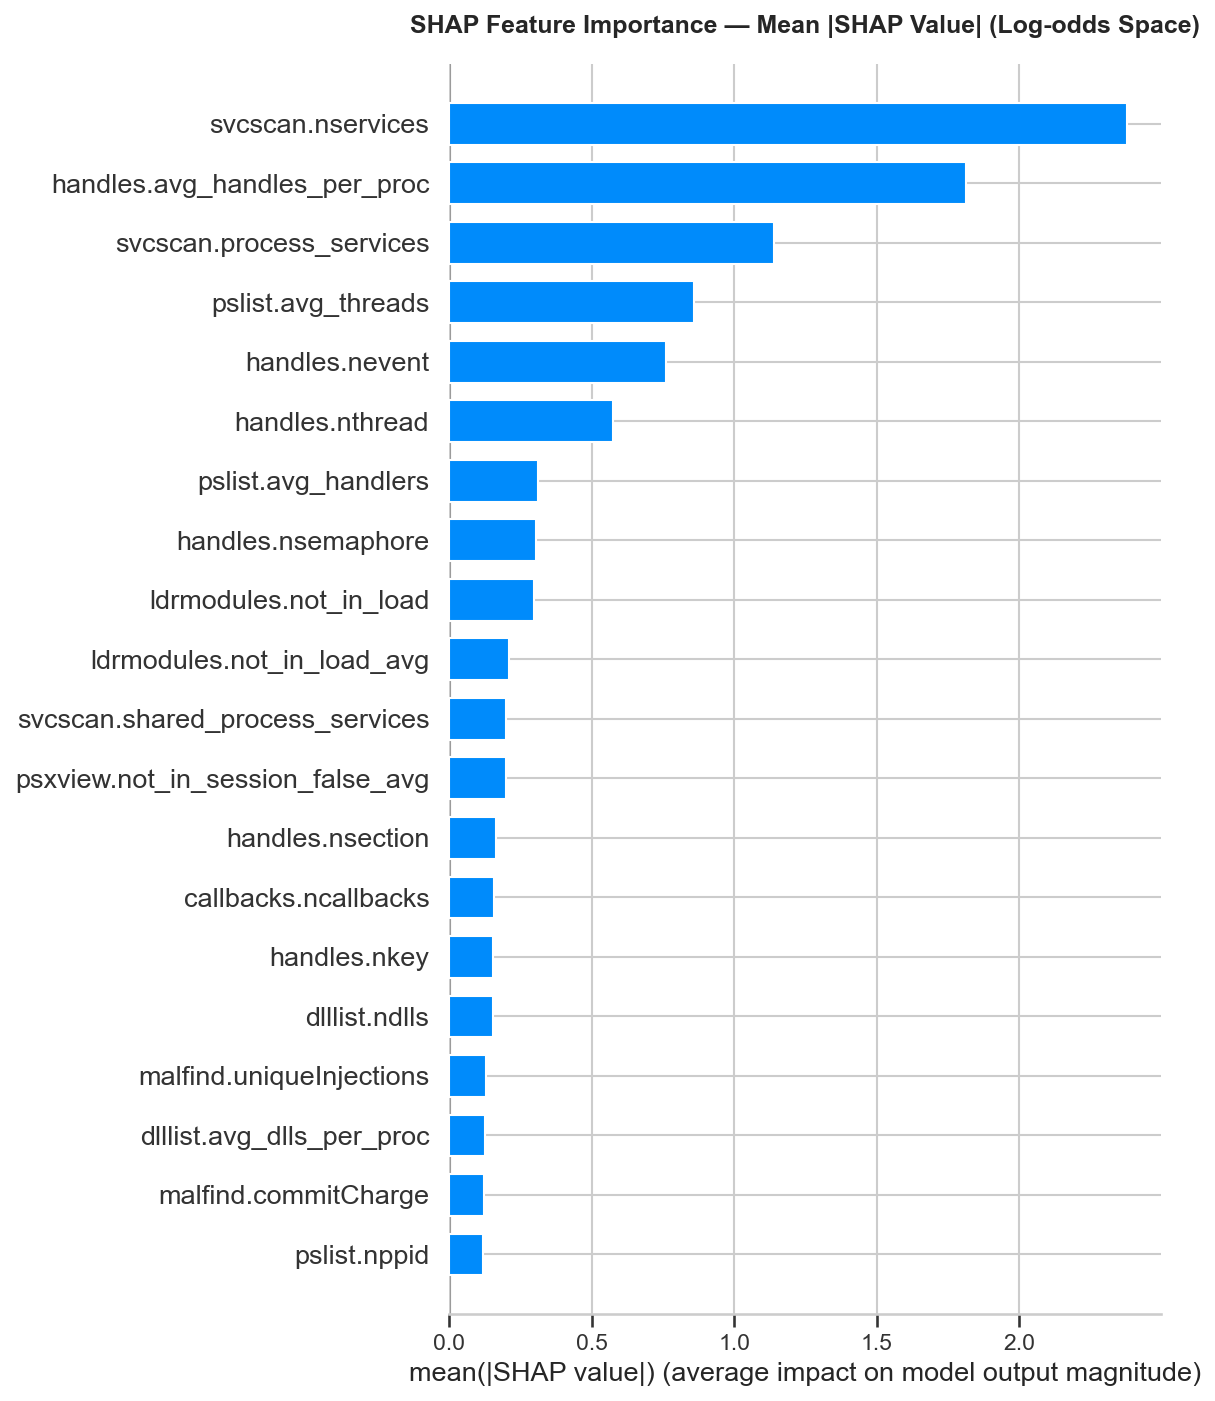

[✓] SHAP plots saved.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6A — SHAP: GLOBAL EXPLAINABILITY [FIX-R6]
#
# SHAP values are in raw margin (log-odds) space — NOT probability space.
# The 500-instance background set is a FIXED-SEED RANDOM SUBSET of the test set.
# (We do not claim stratification — just fixed-seed reproducibility.)
# shap_sample.csv now includes a 'true_label' column for verifiability.
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Computing SHAP values (raw margin / log-odds space)...')
print(f'    Background: fixed-seed random subset of {SHAP_SAMPLE} test instances.')
print(f'    Seed: {RANDOM_STATE} (reproducible, not stratified).')

np.random.seed(RANDOM_STATE)
shap_idx  = np.random.choice(len(X_test_scaled), size=SHAP_SAMPLE, replace=False)
X_shap    = X_test_scaled[shap_idx]
y_shap    = y_test[shap_idx]   # [FIX-R6] store labels for verifiability
X_shap_df = pd.DataFrame(X_shap, columns=feature_cols)

shap_explainer = shap.Explainer(xgb_model, X_shap_df)
shap_values    = shap_explainer(X_shap_df)

print('[✓] SHAP values computed.')
print(f'    Base value (E[log-odds]): {shap_explainer.expected_value:.4f}')
print(f'    Shape of SHAP array    : {shap_values.values.shape}')

# Figure 1: Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_df,
    feature_names=feature_cols,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Beeswarm — Global Feature Importance (Log-odds Space)\n'
    f'Fixed-seed random subset: {SHAP_SAMPLE} test instances | CIC-MalMem-2022',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_beeswarm.png', bbox_inches='tight')
plt.show()

# Figure 2: Bar chart (mean |SHAP|)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap_df,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Feature Importance — Mean |SHAP Value| (Log-odds Space)',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_bar.png', bbox_inches='tight')
plt.show()

print('[✓] SHAP plots saved.')

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 6B — LIME: LOCAL EXPLAINABILITY [FIX-R4, FIX-R5]
#
# [FIX-R4] UNIFIED SIGN CONVENTION:
#   LIME weights are ALWAYS reported relative to class 1 (Malware).
#   Positive weight → supports Malware prediction.
#   Negative weight → supports Benign prediction.
#   This is enforced by always requesting labels=[1] in explain_instance.
#
# [FIX-R5] CASE MANIFEST:
#   lime_case_manifest.csv is exported with: test_row_index, true_label,
#   predicted_label, malware_prob, output_png, output_html.
#   Sample numbering in the manuscript must match this manifest.
#
# [FIX-R4] Thresholds inverse-transformed to ORIGINAL feature units.
# ─────────────────────────────────────────────────────────────────────────────

import re

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_scaled,
    feature_names  = feature_cols,
    class_names    = ['Benign', 'Malware'],
    mode           = 'classification',
    random_state   = RANDOM_STATE
)


def inverse_transform_threshold(lime_list, feature_means, feature_stds, feature_cols):
    """
    Convert LIME threshold strings from standardised space back to original units.
    e.g. 'svcscan.nservices <= 0.55'  →  'svcscan.nservices <= <raw_value>'
    """
    results = []
    for rule, weight in lime_list:
        feat_match = next((f for f in feature_cols if f in rule), None)
        if feat_match:
            idx     = feature_cols.index(feat_match)
            numbers = re.findall(r'[-+]?\d*\.?\d+', rule)
            raw_rule = rule
            for num_str in numbers:
                try:
                    raw_val  = float(num_str) * feature_stds[idx] + feature_means[idx]
                    raw_rule = raw_rule.replace(num_str, f'{raw_val:.2f}', 1)
                except (ValueError, IndexError):
                    pass
            results.append((rule, raw_rule, weight))
        else:
            results.append((rule, rule, weight))
    return results


def explain_instance_lime(test_row_index, output_prefix):
    """
    Generate a LIME explanation for test instance at test_row_index.
    [FIX-R4] Weights always relative to Malware class (labels=[1]).
    [FIX-R5] Returns manifest entry dict for case traceability.
    """
    instance      = X_test_scaled[test_row_index]
    true_label    = y_test[test_row_index]
    pred_label    = xgb_model.predict(instance.reshape(1, -1))[0]
    pred_proba    = xgb_model.predict_proba(instance.reshape(1, -1))[0]
    malware_prob  = pred_proba[1]
    pred_class    = 'Malware' if pred_label == 1 else 'Benign'
    true_class    = 'Malware' if true_label == 1 else 'Benign'

    # [FIX-R4] Always explain w.r.t. Malware class (class index 1)
    exp = lime_explainer.explain_instance(
        data_row   = instance,
        predict_fn = xgb_model.predict_proba,
        num_features = LIME_FEATURES,
        labels     = (1,)   # <-- weights always relative to Malware
    )

    # Get weights for class 1 (Malware)
    lime_weights = exp.as_list(label=1)

    # Inverse-transform to original units
    transformed = inverse_transform_threshold(
        lime_weights, feature_means, feature_stds, feature_cols
    )

    # Print report
    print(f'\n{"─" * 65}')
    print(f'  LIME Forensic Report — Test Row Index: {test_row_index}')
    print(f'  True class      : {true_class}')
    print(f'  Predicted class : {pred_class}  (Malware prob = {malware_prob:.4f})')
    print(f'  Sign convention : weights relative to Malware class (class 1)')
    print(f'  Positive weight → supports Malware | Negative → supports Benign')
    print(f'{"─" * 65}')
    print(f'  {"Feature Rule (z-score)":<45} {"Raw-Unit Predicate":<35} {"Weight":>8}')
    print(f'  {"─" * 45} {"─" * 35} {"─" * 8}')
    for scaled_rule, raw_rule, w in transformed:
        direction = '+Malware' if w > 0 else '-Benign '
        print(f'  {scaled_rule:<45} {raw_rule:<35} {w:+.4f}  [{direction}]')
    print(f'{"─" * 65}')

    # Save HTML (note: HTML sign convention is now class 1 / Malware)
    exp.save_to_file(f'{OUTPUT_DIR}{output_prefix}_lime.html')

    # Save static PNG
    fig = exp.as_pyplot_figure(label=1)
    fig.suptitle(
        f'LIME Local Explanation — Test Row {test_row_index}\n'
        f'True: {true_class} | Predicted: {pred_class} | '
        f'Malware prob: {malware_prob:.4f}\n'
        f'Weights relative to Malware class (class 1)',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{output_prefix}_lime.png', bbox_inches='tight')
    plt.show()
    plt.close()

    # [FIX-R5] Return manifest entry
    return {
        'test_row_index'  : test_row_index,
        'true_label'      : true_class,
        'predicted_label' : pred_class,
        'malware_prob'    : round(float(malware_prob), 6),
        'correct'         : (true_label == pred_label),
        'output_png'      : f'{output_prefix}_lime.png',
        'output_html'     : f'{output_prefix}_lime.html',
    }

[*] Selecting representative LIME cases...
[✓] Malware case: test row index = 1
[✓] Benign  case: test row index = 0

[*] Generating LIME explanation for MALWARE instance...

─────────────────────────────────────────────────────────────────
  LIME Forensic Report — Test Row Index: 1
  True class      : Malware
  Predicted class : Malware  (Malware prob = 1.0000)
  Sign convention : weights relative to Malware class (class 1)
  Positive weight → supports Malware | Negative → supports Benign
─────────────────────────────────────────────────────────────────
  Feature Rule (z-score)                        Raw-Unit Predicate                    Weight
  ───────────────────────────────────────────── ─────────────────────────────────── ────────
  svcscan.nservices <= -0.55                    svcscan.nservices <= 389.00         +0.4770  [+Malware]
  svcscan.process_services <= -0.70             svcscan.process_services <= 24.00   +0.3033  [+Malware]
  -0.25 < handles.avg_handles_per_proc <= -0.

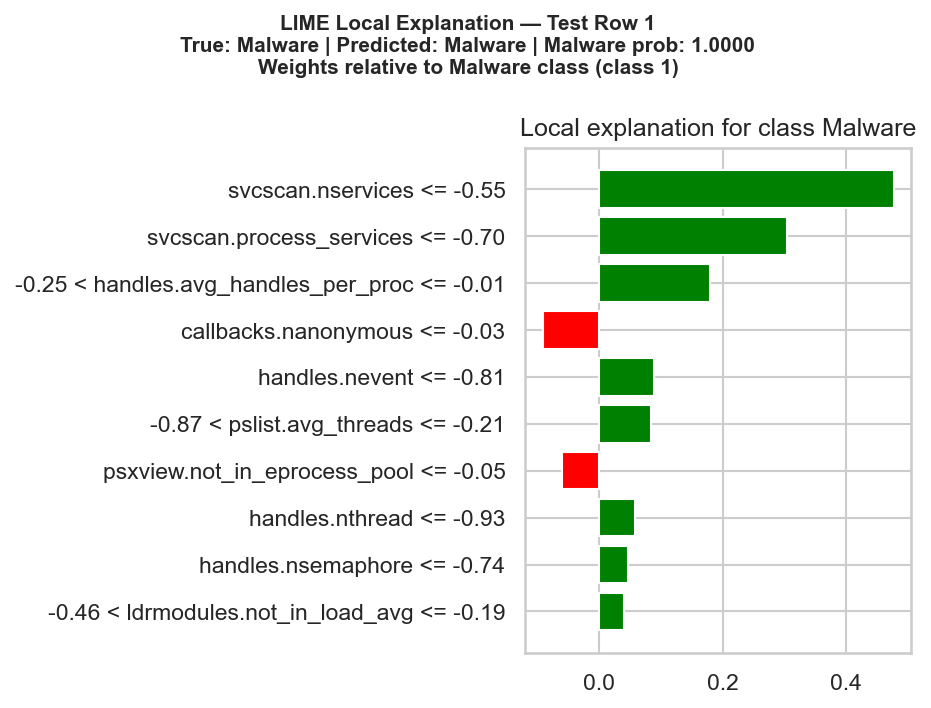


[*] Generating LIME explanation for BENIGN instance...

─────────────────────────────────────────────────────────────────
  LIME Forensic Report — Test Row Index: 0
  True class      : Benign
  Predicted class : Benign  (Malware prob = 0.0001)
  Sign convention : weights relative to Malware class (class 1)
  Positive weight → supports Malware | Negative → supports Benign
─────────────────────────────────────────────────────────────────
  Feature Rule (z-score)                        Raw-Unit Predicate                    Weight
  ───────────────────────────────────────────── ─────────────────────────────────── ────────
  svcscan.process_services <= -0.70             svcscan.process_services <= 24.00   +0.3148  [+Malware]
  -0.55 < svcscan.nservices <= 0.14             389.00 < svcscan.nservices <= 391.98 -0.2638  [-Benign ]
  -0.01 < handles.avg_handles_per_proc <= 0.26  248.33 < handles.avg_handles_per_proc <= 292.15 -0.1916  [-Benign ]
  callbacks.nanonymous <= -0.03                 

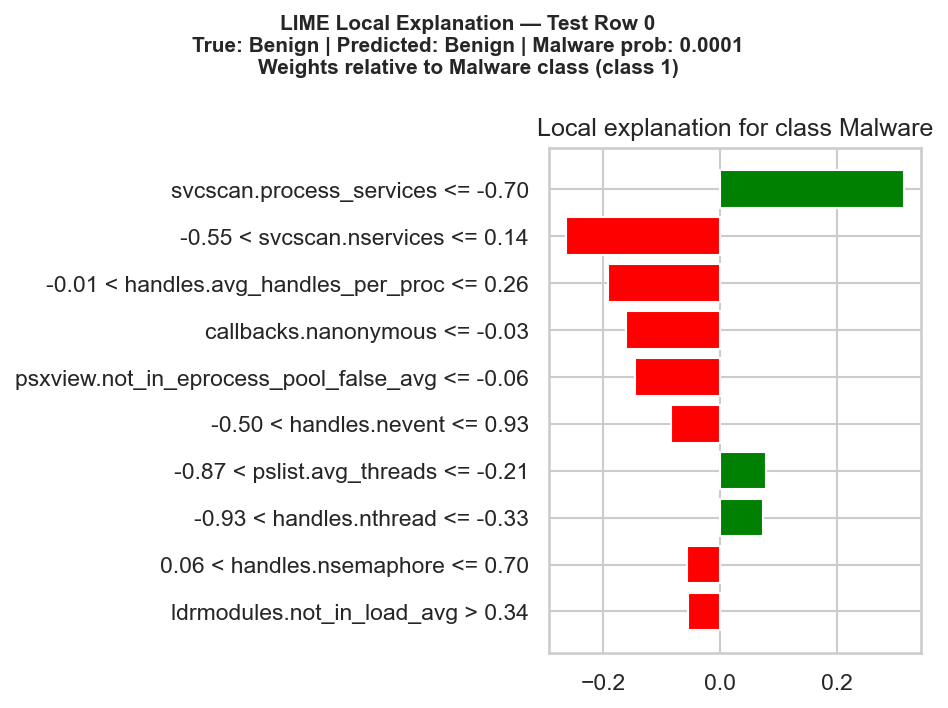


[✓] LIME case manifest saved to lime_case_manifest.csv
[✓] Use test_row_index values in the manuscript to reference these cases.


,test_row_index,true_label,predicted_label,malware_prob,correct,output_png,output_html
0,1,Malware,Malware,0.999961,True,malware_lime.png,malware_lime.html
1,0,Benign,Benign,0.000092,True,benign_lime.png,benign_lime.html


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SELECT LIME CASES [FIX-R5]
#
# Find the first correctly-classified Malware instance and the first
# correctly-classified Benign instance in the test set.
# Record EXACT test-row indices for the case manifest.
# The manuscript must reference these indices (not arbitrary sample names).
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Selecting representative LIME cases...')

# First correctly-predicted Malware instance
malware_candidates = np.where((y_test == 1) & (y_pred == 1))[0]
malware_idx = int(malware_candidates[0])

# First correctly-predicted Benign instance
benign_candidates = np.where((y_test == 0) & (y_pred == 0))[0]
benign_idx = int(benign_candidates[0])

print(f'[✓] Malware case: test row index = {malware_idx}')
print(f'[✓] Benign  case: test row index = {benign_idx}')
print()
print('[*] Generating LIME explanation for MALWARE instance...')
manifest_malware = explain_instance_lime(malware_idx, 'malware')

print('\n[*] Generating LIME explanation for BENIGN instance...')
manifest_benign = explain_instance_lime(benign_idx, 'benign')

# [FIX-R5] Export case manifest
lime_manifest = pd.DataFrame([manifest_malware, manifest_benign])
lime_manifest.to_csv(f'{OUTPUT_DIR}lime_case_manifest.csv', index=False)

print('\n[✓] LIME case manifest saved to lime_case_manifest.csv')
print('[✓] Use test_row_index values in the manuscript to reference these cases.')
display(lime_manifest)

---
## Phase 7 — Model Comparison

[*] Running model comparison (all models use same split and scaling)...
  → Training: XGBoost (Proposed)
  → Training: Random Forest
  → Training: Gradient Boosting
  → Training: MLP (Neural Net)
  → Training: Logistic Regression


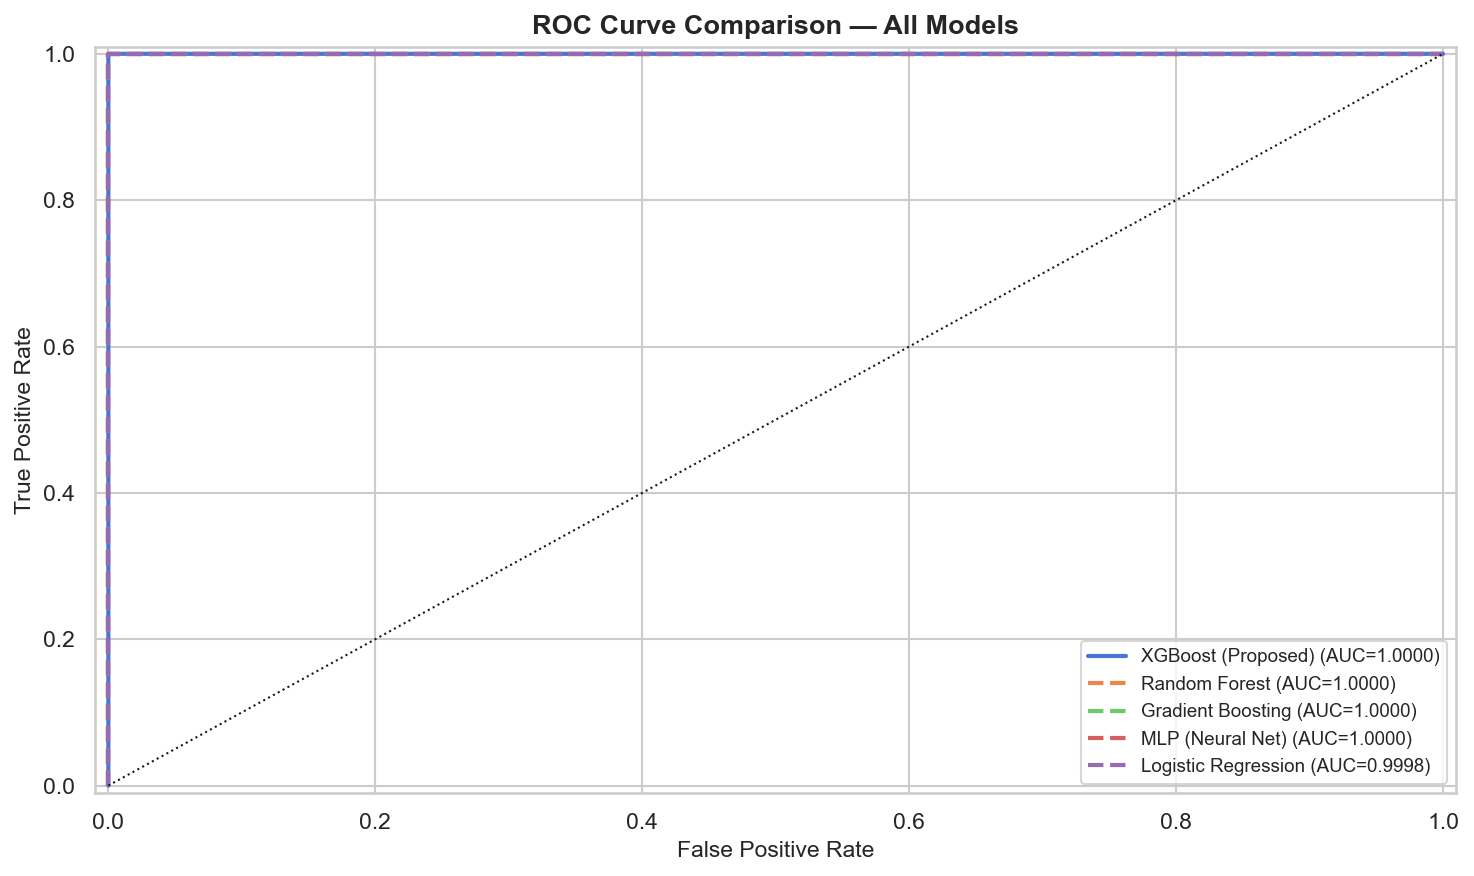


[✓] Model Comparison Results:


,Model,Accuracy,F1-Score,ROC-AUC,MCC
1,XGBoost (Proposed),1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000
3,Gradient Boosting,1.0000,1.0000,1.0000,1.0000
4,MLP (Neural Net),1.0000,1.0000,1.0000,1.0000
5,Logistic Regression,0.9996,0.9996,0.9998,0.9991


In [15]:
print('[*] Running model comparison (all models use same split and scaling)...')

comparison_models = {
    'XGBoost (Proposed)' : xgb_model,
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.05,
                                                       random_state=RANDOM_STATE),
    'MLP (Neural Net)'   : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                          random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results_list = []
fig, ax = plt.subplots(figsize=(10, 6))

for name, mdl in comparison_models.items():
    print(f'  → Training: {name}')
    if name != 'XGBoost (Proposed)':
        mdl.fit(X_train_scaled, y_train)

    preds_m = mdl.predict(X_test_scaled)
    probs_m = mdl.predict_proba(X_test_scaled)[:, 1]

    fpr_m, tpr_m, _ = roc_curve(y_test, probs_m)
    auc_m  = auc(fpr_m, tpr_m)
    acc_m  = accuracy_score(y_test, preds_m)
    f1_m   = f1_score(y_test, preds_m)
    mcc_m  = matthews_corrcoef(y_test, preds_m)

    results_list.append({
        'Model'    : name,
        'Accuracy' : round(acc_m, 4),
        'F1-Score' : round(f1_m, 4),
        'ROC-AUC'  : round(auc_m, 4),
        'MCC'      : round(mcc_m, 4),
    })

    ls = '-' if name == 'XGBoost (Proposed)' else '--'
    ax.plot(fpr_m, tpr_m, lw=2, linestyle=ls,
            label=f'{name} (AUC={auc_m:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_comparison_roc.png', bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1
print('\n[✓] Model Comparison Results:')
display(results_df)
results_df.to_csv(f'{OUTPUT_DIR}model_comparison.csv', index=False)

---
## Phase 8 — Data Integrity & Leakage Audit

| Stage | What it checks |
|-------|----------------|
| **Audit 1** | Exact train/test sample overlap on the *post-clean* split |
| **Audit 2** | Feature–target Pearson correlation (\|r\| > 0.95 threshold) |
| **Audit 3** | 5-fold permutation significance test [FIX-R3] |

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 1 — TRAIN/TEST SAMPLE OVERLAP
# ─────────────────────────────────────────────────────────────────────────────

print('[Audit 1 — Train/Test Overlap]')
print(f'  Context: {df_raw.duplicated().sum()} duplicates removed from raw data BEFORE the split.')
print(f'  The post-clean split should therefore contain zero exact overlaps.')
print()

train_set_tuples = set(map(tuple, X_train.tolist()))
test_set_tuples  = set(map(tuple, X_test.tolist()))
overlap          = train_set_tuples.intersection(test_set_tuples)

n_overlap      = len(overlap)
pct_of_test    = n_overlap / len(X_test) * 100
pct_of_cleaned = n_overlap / len(X)      * 100

print(f'  Post-clean exact bitwise overlaps : {n_overlap}')
print(f'  As % of test set                  : {pct_of_test:.3f}%  ({n_overlap}/{len(X_test):,})')
print(f'  As % of full cleaned dataset      : {pct_of_cleaned:.3f}%  ({n_overlap}/{len(X):,})')

if n_overlap == 0:
    print('  [✓] PASS — Zero overlap. Deduplication-before-split is correctly implemented.')
else:
    print(f'  [⚠️] {n_overlap} near-duplicate rows span the boundary.')
    print('       These survived hash-based deduplication (float-identical rows).')

[Audit 1 — Train/Test Overlap]
  Context: 534 duplicates removed from raw data BEFORE the split.
  The post-clean split should therefore contain zero exact overlaps.

  Post-clean exact bitwise overlaps : 10
  As % of test set                  : 0.086%  (10/11,613)
  As % of full cleaned dataset      : 0.017%  (10/58,062)
  [⚠️] 10 near-duplicate rows span the boundary.
       These survived hash-based deduplication (float-identical rows).


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 2 — FEATURE-TARGET CORRELATION
# ─────────────────────────────────────────────────────────────────────────────

print('[Audit 2 — Feature-Target Correlation]')
print('  Computed on RAW dataset (full coverage, before cleaning).')
print(f'  Leakage screening threshold : |r| > 0.95')
print()

max_corr_feat = correlations.index[0]
max_corr_val  = correlations.iloc[0]
leakage_suspects = correlations[correlations > 0.95].index.tolist()

print(f'  Maximum |r| : {max_corr_val:.4f}  (feature: {max_corr_feat})')

if leakage_suspects:
    print(f'  [⚠️] {len(leakage_suspects)} features with |r| > 0.95 detected.')
    for f in leakage_suspects:
        print(f'    → {f}  (|r| = {correlations[f]:.4f})')
else:
    print('  [✓] PASS — No features with |r| > 0.95. Heuristic screen passed.')
    print('  [NOTE] This does not rule out multivariate proxy leakage structures.')

[Audit 2 — Feature-Target Correlation]
  Computed on RAW dataset (full coverage, before cleaning).
  Leakage screening threshold : |r| > 0.95

  Maximum |r| : 0.9086  (feature: dlllist.avg_dlls_per_proc)
  [✓] PASS — No features with |r| > 0.95. Heuristic screen passed.
  [NOTE] This does not rule out multivariate proxy leakage structures.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 3 — PERMUTATION SIGNIFICANCE TEST [FIX-R3]
#
# [FIX-R3] Key changes from v3:
#   - Uses FULL model config (n_estimators=300, depth=5) — same as main model
#   - cv = N_FOLDS (=5) — matches the main CV protocol stated in the thesis
#   - Uses a Pipeline with fold-internal StandardScaler — consistent with 5B
#   - n_permutations = 1000 — robust p-value (minimum achievable: 1/1001 ≈ 0.001)
#   - p-value: (# perms >= real_score + 1) / (n_perms + 1)  [plus-one correction]
#
# The manuscript can now describe this as a '5-fold permutation control using
# the final model configuration' — consistent with both text and code.
#
# INPUT: X_train (unscaled) — scaler inside Pipeline
# ─────────────────────────────────────────────────────────────────────────────

print('[Audit 3 — Permutation Significance Test]')
print(f'  Model config   : n_estimators=300, max_depth=5 (FINAL model — matches main CV)')
print(f'  CV folds       : {N_FOLDS}  (matches main CV protocol)')
print(f'  Preprocessing  : fold-internal StandardScaler (via Pipeline)')
print(f'  n_permutations : {N_PERMUTATIONS}')
print(f'  Scoring metric : accuracy')
print(f'  p-value formula: (# perms ≥ score + 1) / (n_perms + 1)  [plus-one correction]')
print(f'  Random seed    : {RANDOM_STATE}')
print(f'  Input data     : X_train UNSCALED ({X_train.shape[0]:,} samples)')
print(f'  ⏳ Running... (may take 20–40 min depending on hardware)')
print()

# [FIX-R3] Pipeline with fold-internal scaler + final model config
perm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    xgb.XGBClassifier(**xgb_params))   # FULL final config
])

real_score, perm_scores, p_value = permutation_test_score(
    perm_pipeline,
    X_train,       # <-- UNSCALED: scaler inside Pipeline
    y_train,
    cv             = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                                     random_state=RANDOM_STATE),
    n_permutations = N_PERMUTATIONS,
    scoring        = 'accuracy',
    random_state   = RANDOM_STATE,
    n_jobs         = -1
)

print(f'  Real model accuracy  : {real_score:.4f}')
print(f'  Permuted mean ± std  : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}')
print(f'  Permuted range       : [{perm_scores.min():.4f}, {perm_scores.max():.4f}]')
print(f'  p-value              : {p_value:.6f}  (n={N_PERMUTATIONS}, plus-one correction)')
print()

if p_value < 0.001:
    print('  [✓] STRONG PASS — p < 0.001. Model captures genuine signal.')
elif p_value < 0.01:
    print('  [✓] PASS — p < 0.01. Signal confirmed.')
elif p_value < 0.05:
    print('  [✓] PASS — p < 0.05 (standard significance level).')
else:
    print('  [⚠️] p ≥ 0.05 — results not statistically significant at standard level.')

# Permutation distribution plot
plt.figure(figsize=(8, 4))
plt.hist(perm_scores, bins=30, color='steelblue', edgecolor='white', alpha=0.8,
         label=f'Permuted scores (n={N_PERMUTATIONS})')
plt.axvline(x=real_score, color='red', lw=2, linestyle='--',
            label=f'Real model score: {real_score:.4f}')
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.title(
    f'5-Fold Permutation Test (n={N_PERMUTATIONS}, p = {p_value:.4f})\n'
    'Final model config | Fold-internal StandardScaler',
    fontweight='bold'
)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}permutation_test.png', bbox_inches='tight')
plt.show()

print('[✓] Permutation audit complete.')

[Audit 3 — Permutation Significance Test]
  Model config   : n_estimators=300, max_depth=5 (FINAL model — matches main CV)
  CV folds       : 5  (matches main CV protocol)
  Preprocessing  : fold-internal StandardScaler (via Pipeline)
  n_permutations : 1000
  Scoring metric : accuracy
  p-value formula: (# perms ≥ score + 1) / (n_perms + 1)  [plus-one correction]
  Random seed    : 42
  Input data     : X_train UNSCALED (46,449 samples)
  ⏳ Running... (may take 20–40 min depending on hardware)



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SYNTHETIC FEATURE PERTURBATION TEST
#
# Gaussian noise added to the standardised test features.
# This is a synthetic sensitivity check — NOT a claim about operational
# memory-acquisition noise, parser instability, or adversarial robustness.
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Synthetic Feature Perturbation Test...')
print('    (Gaussian noise on standardised features — not operational noise)')

noise_levels = [0.000, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
noise_results = []

for sigma in noise_levels:
    rng = np.random.default_rng(RANDOM_STATE)
    X_noisy     = X_test_scaled + rng.normal(0, sigma, X_test_scaled.shape)
    noisy_preds = xgb_model.predict(X_noisy)
    noisy_acc   = accuracy_score(y_test, noisy_preds)
    noise_results.append({'Noise_sigma': sigma, 'Accuracy': noisy_acc})
    print(f'  σ = {sigma:.3f} → Accuracy: {noisy_acc:.4f}')

noise_df = pd.DataFrame(noise_results)

plt.figure(figsize=(8, 4))
plt.plot(noise_df['Noise_sigma'], noise_df['Accuracy'], 'o-', color='steelblue', lw=2)
plt.axhline(y=test_acc, color='gray', linestyle='--',
            label=f'Clean baseline ({test_acc:.4f})')
plt.xlabel('Gaussian Noise σ (applied to standardised features)')
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Under Synthetic Feature Perturbation\n'
          '(Not operational noise — controlled sensitivity check)',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}noise_robustness.png', bbox_inches='tight')
plt.show()

print('[✓] Synthetic perturbation test complete.')

---
## Phase 9 — Artifact Export

In [ ]:
print('[*] Saving all artifacts to', OUTPUT_DIR)

# ── Model & Scaler
joblib.dump(xgb_model, f'{OUTPUT_DIR}xgboost_malware_model.pkl')
joblib.dump(scaler,    f'{OUTPUT_DIR}standard_scaler.pkl')

# ── SHAP values  [FIX-R6: includes true_label column]
np.save(f'{OUTPUT_DIR}shap_values.npy', shap_values.values)
shap_sample_df = pd.DataFrame(X_shap, columns=feature_cols)
shap_sample_df['true_label'] = ['Malware' if l == 1 else 'Benign' for l in y_shap]
shap_sample_df.to_csv(f'{OUTPUT_DIR}shap_sample.csv', index=False)

# ── Test predictions  [FIX-R5: includes test_row_index]
test_export = pd.DataFrame({
    'test_row_index' : range(len(y_test)),
    'True_Label'     : ['Malware' if l == 1 else 'Benign' for l in y_test],
    'Predicted_Label': ['Malware' if p == 1 else 'Benign' for p in y_pred],
    'Malware_Prob'   : y_proba,
    'Correct'        : (y_test == y_pred)
})
test_export.to_csv(f'{OUTPUT_DIR}test_predictions.csv', index=False)

# ── Feature importance
feat_importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_importance_df.to_csv(f'{OUTPUT_DIR}feature_importance.csv', index=False)

# ── Metrics summary
pd.DataFrame([metrics]).to_csv(f'{OUTPUT_DIR}metrics_summary.csv', index=False)

# ── Permutation test results
pd.DataFrame({
    'real_score'       : [real_score],
    'perm_mean'        : [perm_scores.mean()],
    'perm_std'         : [perm_scores.std()],
    'p_value'          : [p_value],
    'n_permutations'   : [N_PERMUTATIONS],
    'cv_folds'         : [N_FOLDS],
    'model_config'     : ['final (n_est=300, depth=5)'],
    'preprocessing'    : ['fold-internal StandardScaler']
}).to_csv(f'{OUTPUT_DIR}permutation_test_results.csv', index=False)

# ── Noise robustness
noise_df.to_csv(f'{OUTPUT_DIR}noise_robustness_results.csv', index=False)

# ── LIME case manifest [FIX-R5]
# (already saved in Phase 6; confirm it exists)
print('[✓] lime_case_manifest.csv saved in Phase 6.')

# ── Final summary
print('\n' + '═' * 65)
print('  PIPELINE COMPLETE — v4 (All Reviewer Issues Resolved)')
print('═' * 65)
print(f'  Dataset        : CIC-MalMem-2022')
print(f'  Total Samples  : {len(df):,}  (train: {len(X_train):,} | test: {len(X_test):,})')
print(f'  Features Used  : {len(feature_cols)}')
print()
for metric, value in metrics.items():
    print(f'  {metric:<25}: {value:.4f}')
print()
print(f'  CV (5-fold, fold-internal scaler)  : {cv_results["test_accuracy"].mean():.4f} ± {cv_results["test_accuracy"].std():.4f}')
print(f'  Permutation p-value (5-fold, n=1000): {p_value:.4f}')
print(f'  LIME Malware case  : test row index {manifest_malware["test_row_index"]}')
print(f'  LIME Benign  case  : test row index {manifest_benign["test_row_index"]}')
print(f'  SHAP sample        : {SHAP_SAMPLE} fixed-seed random test instances')
print(f'  Output Dir         : {os.path.abspath(OUTPUT_DIR)}')
print('═' * 65)

# Artifact checklist
artifacts = [
    'xgboost_malware_model.pkl', 'standard_scaler.pkl',
    'shap_values.npy', 'shap_sample.csv',
    'test_predictions.csv', 'feature_importance.csv',
    'metrics_summary.csv', 'model_comparison.csv',
    'permutation_test_results.csv', 'noise_robustness_results.csv',
    'lime_case_manifest.csv',
    'eda_dashboard.png', 'evaluation_dashboard.png',
    'shap_beeswarm.png', 'shap_bar.png',
    'malware_lime.png', 'malware_lime.html',
    'benign_lime.png',  'benign_lime.html',
    'model_comparison_roc.png', 'noise_robustness.png',
    'permutation_test.png',
]

print('\n  Artifact Checklist:')
for artifact in artifacts:
    path   = f'{OUTPUT_DIR}{artifact}'
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  [{status}] {artifact}')